Data Augmentation on 1 image



In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing import image
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [6]:
img = image.load_img('/content/cat', target_size = (200,200))

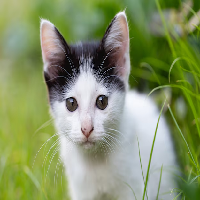

In [7]:
img

In [8]:
datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2
)

In [9]:
img = image.img_to_array(img)

In [10]:
type(img)

numpy.ndarray

In [11]:
input_batch = img.reshape((1, 200, 200, 3))

In [12]:
mkdir -p '/content/aug'

In [13]:
i = 0

for output in datagen.flow(input_batch, batch_size = 1, save_to_dir = '/content/aug'):
    i = i+1

    if(i == 10):
      break

In [14]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [15]:
from keras.src.layers.reshaping.flatten import Flatten
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

In [25]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/dogsvscats/train',
    target_size = (256,256),
    batch_size = 16,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/dogsvscats/test',
    target_size = (256,256),
    batch_size = 16,
    class_mode = 'binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [18]:
from keras.layers import BatchNormalization, Dropout

In [20]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer = 'adam', loss= 'binary_crossentropy', metrics=['accuracy'])

In [27]:
history = model.fit(train_generator, epochs = 10, validation_data=validation_generator)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 412s 321ms/step - accuracy: 0.5792 - loss: 1.6921 - val_accuracy: 0.6892 - val_loss: 0.5894
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 336s 268ms/step - accuracy: 0.6841 - loss: 0.5938 - val_accuracy: 0.6822 - val_loss: 0.5950
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 348s 278ms/step - accuracy: 0.7226 - loss: 0.5496 - val_accuracy: 0.7400 - val_loss: 0.5795
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 339s 271ms/step - accuracy: 0.7679 - loss: 0.4898 - val_accuracy: 0.7960 - val_loss: 0.4362
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 338s 270ms/step - accuracy: 0.8016 - loss: 0.4405 - val_accuracy: 0.7828 - val_loss: 0.4780
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 342s 273ms/step - accuracy: 0.7966 - loss: 0.4543 - val_accuracy: 0.8246 - val_loss: 0.4059
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 338s 270ms/step - accuracy: 0.8309 - loss: 0.3836 - val_accuracy: 0.8240 - val_loss: 0.4053
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 341s 273ms/step - ac

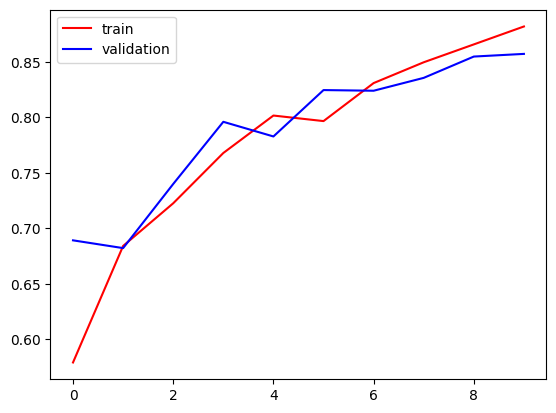

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

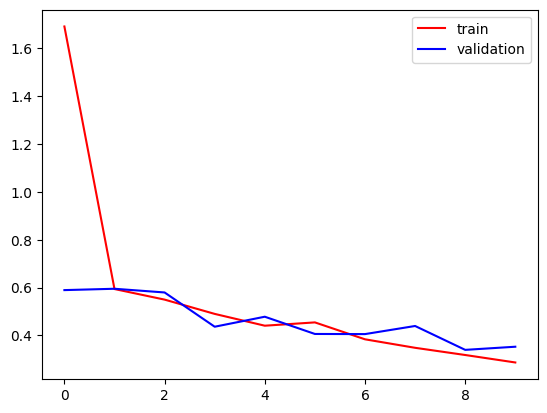

In [29]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

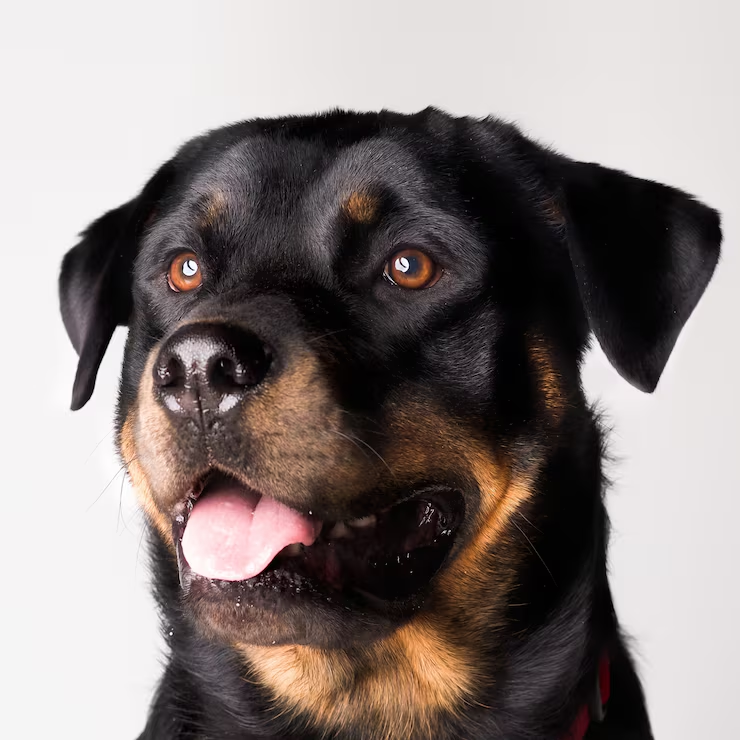

(740, 740, 3)

In [30]:
import cv2
from google.colab.patches import cv2_imshow
test_img = cv2.imread('/content/dog')
cv2_imshow(test_img)
test_img.shape

In [31]:
test_img = cv2.resize(test_img, (256,256))

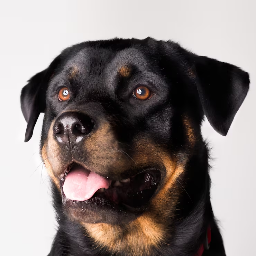

In [32]:
cv2_imshow(test_img)

In [33]:
test_input = test_img.reshape((1,256,256,3))

In [34]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)